# 1️⃣ Setup Environment

## Import libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np
import os
import gc
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning - model selection
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

# Utilities
from collections import Counter
from IPython.display import display

## Settings

In [2]:
# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Confirmation message
print("Display settings configured and random seed set.")

Display settings configured and random seed set.


# 2️⃣ Load & Inspect Datasets

## List all dataset files

In [3]:
# Define the folder containing the datasets
dataset_folder = "Dataset"

# List all dataset files
dataset_files = [f for f in os.listdir(dataset_folder) if f.endswith('.csv')]
print("Found dataset files:")
for file in dataset_files:
    print(f" - {file}")
print("Dataset files listed successfully.")

Found dataset files:
 - 02-14-2018.csv
 - 02-15-2018.csv
 - 02-16-2018.csv
 - 02-20-2018.csv
 - 02-21-2018.csv
 - 02-22-2018.csv
 - 02-23-2018.csv
 - 02-28-2018.csv
 - 03-01-2018.csv
 - 03-02-2018.csv
Dataset files listed successfully.


## Inspect each dataset

In [4]:
for file in dataset_files:
    print("="*80)
    print(f"Dataset: {file}")
    print("="*80)
    
    # Load dataset
    df = pd.read_csv(os.path.join(dataset_folder, file))
    
    # Preview first 5 rows
    print("\nHead (first 5 rows):")
    display(df.head())
    
    # Info: columns, non-null counts, dtypes
    print("\nInfo:")
    display(pd.DataFrame(df.dtypes, columns=['Data Type']))
    
    # Basic statistics for numeric columns
    print("\nDescribe (numeric stats):")
    display(df.describe())
    
    # Missing values
    print("\nMissing Values:")
    missing = df.isnull().sum()
    missing = missing[missing > 0] 
    if missing.empty:
        print("No missing values")
    else:
        display(missing.to_frame('Missing Count'))
    
    print("Inspection complete for this dataset.\n\n")

Dataset: 02-14-2018.csv

Head (first 5 rows):


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,0.027,56320859.500,139.300,56320958,56320761,112641719,56320859.500,139.300,56320958,56320761,0,0.000,0.000,0,0,0,0,0,0,0,0,0.027,0.000,0,0,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.000,0.000,0,0,56320859.500,139.300,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,0.027,56320733.000,114.551,56320814,56320652,112641466,56320733.000,114.551,56320814,56320652,0,0.000,0.000,0,0,0,0,0,0,0,0,0.027,0.000,0,0,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.000,0.000,0,0,56320733.000,114.551,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,0.027,56319311.500,301.935,56319525,56319098,112638623,56319311.500,301.935,56319525,56319098,0,0.000,0.000,0,0,0,0,0,0,0,0,0.027,0.000,0,0,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.000,0.000,0,0,56319311.500,301.935,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,82.600,196.741,976,0,227.300,371.678,544.162,3.874,268915.250,247443.779,673900,22,6453966,460997.571,123109.424,673900,229740,5637902,626433.556,455082.214,1167293,554,0,0,0,0,488,328,2.324,1.549,0,976,135.077,277.835,77192.154,0,0,0,1,0,0,0,0,0,140.480,82.600,227.300,0,0,0,0,0,0,15,1239,10,2273,65535,233,6,32,0.000,0.000,0,0,0.000,0.000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,81.643,203.746,976,0,200.818,362.250,380.733,2.840,366836.083,511356.610,1928102,21,8804066,677235.846,532416.971,1928102,246924,7715481,771548.100,755543.083,2174893,90,0,0,0,0,456,360,1.590,1.249,0,976,128.923,279.763,78267.354,0,0,0,1,0,0,0,0,0,134.080,81.643,200.818,0,0,0,0,0,0,14,1143,11,2209,5808,233,6,32,0.000,0.000,0,0,0.000,0.000,0,0,Benign



Info:


,Data Type
Dst Port,int64
Protocol,int64
Timestamp,str
Flow Duration,int64
Tot Fwd Pkts,int64
Tot Bwd Pkts,int64
TotLen Fwd Pkts,int64
TotLen Bwd Pkts,int64
Fwd Pkt Len Max,int64
Fwd Pkt Len Min,int64



Describe (numeric stats):


...

c:\Users\Dokbrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\Dokbrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1046017.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000,1048575.000
mean,8423.429,8.050,11514208.720,5.887,6.983,392.084,5271.275,210.431,8.249,54.616,77.961,347.121,19.418,102.797,125.711,inf,inf,4259831.844,707730.828,6325741.929,3939930.137,11242027.237,4497207.237,767643.483,6149987.919,4019517.904,6282780.706,535165.597,635147.785,1913999.875,127674.607,0.030,0.000,0.000,0.000,123.750,144.536,17361.536,2415.057,8.104,380.390,74.114,115.049,35943.989,0.004,0.030,0.264,0.457,0.335,0.030,0.000,0.264,0.480,83.795,54.616,102.797,0.000,0.000,0.000,0.000,0.000,0.000,5.887,392.084,6.983,5271.101,6925.808,11235.907,2.044,17.454,122957.853,61309.720,190523.055,83054.457,4781197.351,106422.422,4863777.337,4677016.563
std,15161.757,4.433,30121132.472,89.033,212.958,2159.779,308876.832,266.950,20.950,57.628,96.933,503.728,45.464,166.013,194.865,NaN,NaN,16775355.049,2973323.492,18965289.631,16781722.039,30004943.239,16847782.386,3374034.834,18827707.724,16854778.182,23490114.441,2603409.651,2722331.630,8401695.568,2047740.242,0.172,0.000,0.000,0.000,3901.928,4241.628,162131.144,38386.630,19.243,495.702,107.747,150.691,74989.884,0.061,0.172,0.441,0.498,0.472,0.172,0.000,0.441,0.829,111.846,57.628,166.013,0.000,0.000,0.000,0.000,0.000,0.000,89.033,2159.779,212.958,308766.063,12733.945,23668.480,13.925,5.180,2083098.855,1261694.004,2761455.530,1759831.613,17413075.114,1462605.490,17568079.177,17333032.005
min,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.017,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,-1.000,-1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,80.000,6.000,516.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,6.796,495.000,0.000,500.000,11.000,173.000,146.000,0.000,166.


Missing Values:


,Missing Count
Flow Byts/s,2558


Inspection complete for this dataset.




## Preview each dataset Label column

In [5]:
label_info = {}

for file in dataset_files:
    file_path = os.path.join(dataset_folder, file)
    df = pd.read_csv(file_path, low_memory=False)
    
    if 'Label' in df.columns:
        value_counts = df['Label'].value_counts(normalize=True) * 100
        label_info[file] = {
            'Label_column_present': True,
            'unique_values_count': df['Label'].nunique(),
            'unique_values_names': df['Label'].unique(),
            'value_percentages': value_counts.to_dict()
        }
    else:
        label_info[file] = {
            'Label_column_present': False,
            'unique_values_count': 0,
            'unique_values_names': [],
            'value_percentages': {}
        }

# Display summary
for file, info in label_info.items():
    print(f"{file}:")
    print(f"  Label column present = {info['Label_column_present']}")
    print(f"  Unique values count = {info['unique_values_count']}")
    print(f"  Unique value names = {info['unique_values_names']}")
    print(f"  Value percentages:")
    for label, pct in info['value_percentages'].items():
        print(f"    {label}: {pct:.2f}%")
    print("-" * 50)

print("Label column inspection completed with percentages.")

02-14-2018.csv:
  Label column present = True
  Unique values count = 3
  Unique value names = <StringArray>
['Benign', 'FTP-BruteForce', 'SSH-Bruteforce']
Length: 3, dtype: str
  Value percentages:
    Benign: 63.67%
    FTP-BruteForce: 18.44%
    SSH-Bruteforce: 17.89%
--------------------------------------------------
02-15-2018.csv:
  Label column present = True
  Unique values count = 3
  Unique value names = <StringArray>
['Benign', 'DoS attacks-GoldenEye', 'DoS attacks-Slowloris']
Length: 3, dtype: str
  Value percentages:
    Benign: 94.99%
    DoS attacks-GoldenEye: 3.96%
    DoS attacks-Slowloris: 1.05%
--------------------------------------------------
02-16-2018.csv:
  Label column present = True
  Unique values count = 4
  Unique value names = <StringArray>
['Benign', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Hulk', 'Label']
Length: 4, dtype: str
  Value percentages:
    DoS attacks-Hulk: 44.05%
    Benign: 42.61%
    DoS attacks-SlowHTTPTest: 13.34%
    Label: 0.00%
------

# 3️⃣ Merge Datasets

## Load each selected dataset

In [6]:
# Load selected datasets into a list of DataFrames
selected_files = [
    '02-14-2018.csv',  # FTP-BruteForce / SSH-Bruteforce
    '02-16-2018.csv',  # DoS attacks-Hulk
    '02-20-2018.csv',  # DDoS attacks-LOIC-HTTP
    '02-21-2018.csv',  # DDoS attacks-HOIC
    '03-02-2018.csv'   # Bot
]

dataframes = []

for file in selected_files:
    file_path = os.path.join(dataset_folder, file)
    df = pd.read_csv(file_path, low_memory=False)
    dataframes.append(df)
    print(f"{file} loaded, shape: {df.shape}")

print("All selected datasets loaded into memory as separate DataFrames.")

02-14-2018.csv loaded, shape: (1048575, 80)
02-16-2018.csv loaded, shape: (1048575, 80)
02-20-2018.csv loaded, shape: (7948748, 84)
02-21-2018.csv loaded, shape: (1048575, 80)
03-02-2018.csv loaded, shape: (1048575, 80)
All selected datasets loaded into memory as separate DataFrames.


## Merge, Save, and Free Memory

In [7]:
# Merge all selected datasets into a single DataFrame
merged_df = pd.concat(dataframes, ignore_index=True)
print(f"Datasets merged successfully. Merged shape: {merged_df.shape}")

# Preview first 5 rows
display(merged_df.head())

# Save merged dataset for future use
merged_df.to_csv("merged_dataset.csv", index=False)
print("Merged dataset saved as 'merged_dataset.csv'.")

# Free memory by deleting individual DataFrames
del dataframes
print("Individual DataFrames cleared from memory.")

Datasets merged successfully. Merged shape: (12143048, 84)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,0.027,56320859.500,139.300,56320958,56320761,112641719,56320859.500,139.300,56320958,56320761,0,0.000,0.000,0,0,0,0,0,0,0,0,0.027,0.000,0,0,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.000,0.000,0,0,56320859.500,139.300,56320958,56320761,Benign,NaN,NaN,NaN,NaN
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,0.027,56320733.000,114.551,56320814,56320652,112641466,56320733.000,114.551,56320814,56320652,0,0.000,0.000,0,0,0,0,0,0,0,0,0.027,0.000,0,0,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.000,0.000,0,0,56320733.000,114.551,56320814,56320652,Benign,NaN,NaN,NaN,NaN
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,0.000,0.000,0,0,0.000,0.000,0.000,0.027,56319311.500,301.935,56319525,56319098,112638623,56319311.500,301.935,56319525,56319098,0,0.000,0.000,0,0,0,0,0,0,0,0,0.027,0.000,0,0,0.000,0.000,0.000,0,0,0,0,0,0,0,0,0,0.000,0.000,0.000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.000,0.000,0,0,56319311.500,301.935,56319525,56319098,Benign,NaN,NaN,NaN,NaN
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,82.600,196.741,976,0,227.300,371.678,544.162,3.874,268915.250,247443.779,673900,22,6453966,460997.571,123109.424,673900,229740,5637902,626433.556,455082.214,1167293,554,0,0,0,0,488,328,2.324,1.549,0,976,135.077,277.835,77192.154,0,0,0,1,0,0,0,0,0,140.480,82.600,227.300,0,0,0,0,0,0,15,1239,10,2273,65535,233,6,32,0.000,0.000,0,0,0.000,0.000,0,0,Benign,NaN,NaN,NaN,NaN
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,81.643,203.746,976,0,200.818,362.250,380.733,2.840,366836.083,511356.610,1928102,21,8804066,677235.846,532416.971,1928102,246924,7715481,771548.100,755543.083,2174893,90,0,0,0,0,456,360,1.590,1.249,0,976,128.923,279.763,78267.354,0,0,0,1,0,0,0,0,0,134.080,81.643,200.818,0,0,0,0,0,0,14,1143,11,2209,5808,233,6,32,0.000,0.000,0,0,0.000,0.000,0,0,Benign,NaN,NaN,NaN,NaN


Merged dataset saved as 'merged_dataset.csv'.
Individual DataFrames cleared from memory.


# 4️⃣ Initial Exploration

## Check missing values and duplicates

In [8]:
# Check for missing values
missing_values = merged_df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if missing_values.empty:
    print("No missing values detected in the merged dataset.")
else:
    print("Columns with missing values:")
    display(missing_values.to_frame(name='Missing Count'))

# Check for duplicates
duplicate_count = merged_df.duplicated().sum()
if duplicate_count == 0:
    print("No duplicate rows detected in the merged dataset.")
else:
    print(f"Found {duplicate_count} duplicate rows.")

Columns with missing values:


,Missing Count
Flow Byts/s,41602
Flow ID,4194300
Src IP,4194300
Src Port,4194300
Dst IP,4194300


Found 396232 duplicate rows.


## Explore target variable distribution

Target variable distribution (Label):
 - Benign: 9610172 rows (79.14%)
 - DDOS attack-HOIC: 686012 rows (5.65%)
 - DDoS attacks-LOIC-HTTP: 576191 rows (4.75%)
 - DoS attacks-Hulk: 461912 rows (3.80%)
 - Bot: 286191 rows (2.36%)
 - FTP-BruteForce: 193360 rows (1.59%)
 - SSH-Bruteforce: 187589 rows (1.54%)
 - DoS attacks-SlowHTTPTest: 139890 rows (1.15%)
 - DDOS attack-LOIC-UDP: 1730 rows (0.01%)
 - Label: 1 rows (0.00%)


C:\Users\Dokbrac\AppData\Local\Temp\ipykernel_22740\1897861952.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


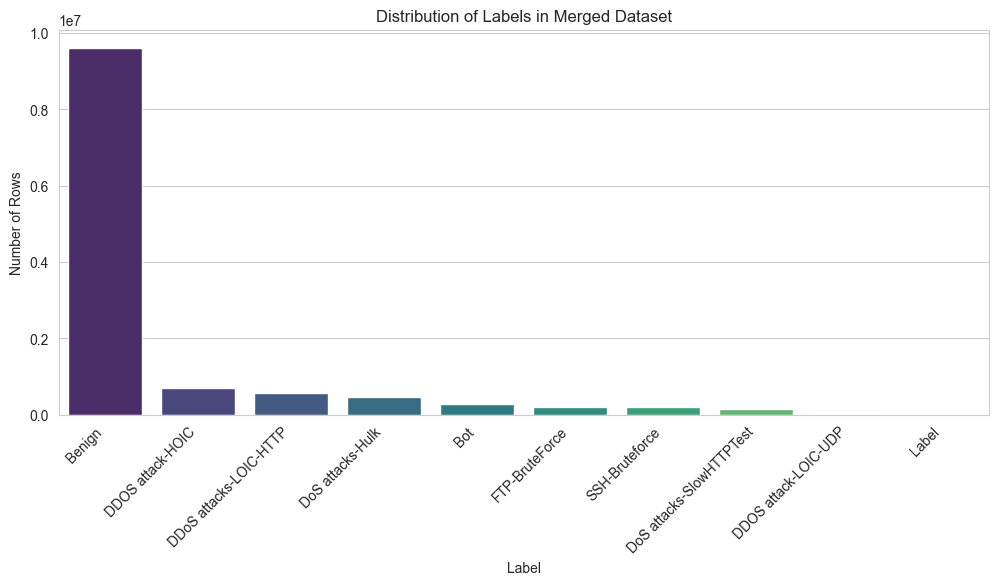

In [9]:
# Check if Label column exists
if 'Label' in merged_df.columns:
    label_counts = merged_df['Label'].value_counts()
    label_percentages = merged_df['Label'].value_counts(normalize=True) * 100

    print("Target variable distribution (Label):")
    for label, count in label_counts.items():
        pct = label_percentages[label]
        print(f" - {label}: {count} rows ({pct:.2f}%)")
    
    # Quick bar plot
    plt.figure(figsize=(12,5))
    sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Number of Rows')
    plt.title('Distribution of Labels in Merged Dataset')
    plt.show()
else:
    print("Label column not found in merged dataset.")

## Update merged dataset

In [10]:
# Load the existing merged dataset
merged_df = pd.read_csv("merged_dataset.csv", low_memory=False)

print("Before cleaning:", merged_df.shape)

# Remove bad rows where Label == Label
merged_df = merged_df[merged_df['Label'] != 'Label']

print("After cleaning:", merged_df.shape)

# Overwrite the SAME file (updated dataset)
merged_df.to_csv("merged_dataset.csv", index=False)

print("merged_dataset.csv updated successfully")

# Check labels again
print("\nUpdated Label distribution:")
print(merged_df['Label'].value_counts())

Before cleaning: (12143048, 84)
After cleaning: (12143047, 84)
merged_dataset.csv updated successfully

Updated Label distribution:
Label
Benign                      9610172
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DDOS attack-LOIC-UDP           1730
Name: count, dtype: int64


## Visualize feature distributions

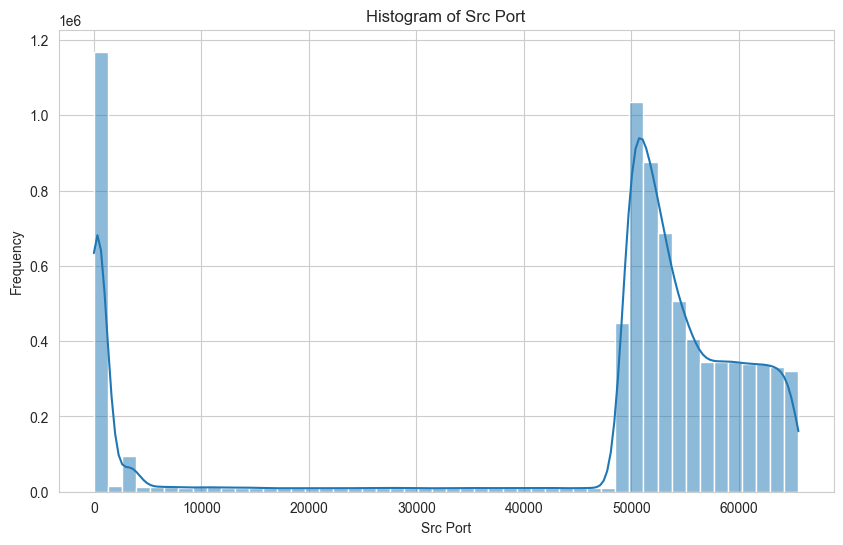

Histograms plotted for first 10 numeric features.


In [11]:
# Select numeric columns
numeric_cols = merged_df.select_dtypes(include=np.number).columns.tolist()

# Plot histograms for the first 10 numeric features
for col in numeric_cols[:10]:
    plt.figure()
    sns.histplot(merged_df[col], bins=50, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

print("Histograms plotted for first 10 numeric features.")

# 5️⃣ Early Baseline with Minimal Preprocessing

In [ ]:
print("Running EARLY baseline with minimal preprocessing")

# Copy dataset (avoid modifying original)
merged_df_baseline = merged_df.copy()

# Remove obvious bad rows
merged_df_baseline = merged_df_baseline[merged_df_baseline['Label'] != 'Label']

# Simple missing handling
merged_df_baseline = merged_df_baseline.fillna(0)

# Encode target ONLY
le_baseline = LabelEncoder()
merged_df_baseline['Label_encoded'] = le_baseline.fit_transform(merged_df_baseline['Label'])

# Use ALL numeric features (NO feature selection)
X_baseline = merged_df_baseline.select_dtypes(include=np.number).drop(columns=['Label_encoded'])
y_baseline = merged_df_baseline['Label_encoded']

print(f"Features used: {X_baseline.shape[1]} (no feature selection)")

# Train-test split
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_baseline, y_baseline,
    test_size=0.3,
    random_state=42,
    stratify=y_baseline
)

print("Train-test split complete")

# Train model
rf_baseline_early = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_baseline_early.fit(X_train_b, y_train_b)

# Predict
y_pred_b = rf_baseline_early.predict(X_test_b)

# Evaluate
accuracy_b = accuracy_score(y_test_b, y_pred_b)
f1_weighted_b = f1_score(y_test_b, y_pred_b, average='weighted')
f1_macro_b = f1_score(y_test_b, y_pred_b, average='macro')

print("\nEARLY BASELINE RESULTS:")
print(f"Accuracy: {accuracy_b:.4f}")
print(f"F1-weighted: {f1_weighted_b:.4f}")
print(f"F1-macro: {f1_macro_b:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_b, y_pred_b))

# Save model + results
early_baseline_results = {
    "accuracy": accuracy_b,
    "f1_weighted": f1_weighted_b,
    "f1_macro": f1_macro_b
}

joblib.dump(rf_baseline_early, "rf_early_baseline_model.pkl")
joblib.dump(early_baseline_results, "early_baseline_results.pkl")

print("Early baseline model, results, and encoder saved")

# Clean up RAM
del rf_baseline_early, y_pred_b, early_baseline_results, merged_df_baseline
gc.collect()

print("RAM cleaned after early baseline")

Running EARLY baseline with minimal preprocessing
Features used: 1 (no feature selection)
Train-test split complete

EARLY BASELINE RESULTS:
Accuracy: 0.3285
F1-weighted: 0.4169
F1-macro: 0.0865

Classification Report:


c:\Users\Dokbrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dokbrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dokbrac\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

           0       0.98      0.35      0.51   2883052
           1       0.00      0.00      0.00     85857
           2       0.00      0.00      0.00    205804
           3       0.00      0.00      0.00       519
           4       0.11      0.87      0.20    172857
           5       0.00      0.00      0.00    138574
           6       0.03      1.00      0.06     41967
           7       0.00      0.00      0.00     58008
           8       0.00      0.00      0.00     56277

    accuracy                           0.33   3642915
   macro avg       0.13      0.25      0.09   3642915
weighted avg       0.78      0.33      0.42   3642915

Early baseline model, results, and encoder saved
RAM cleaned after early baseline


# 6️⃣ Preprocessing

## Handle missing values

In [13]:
# Check missing values
missing_counts = merged_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
print("Columns with missing values before handling:")
display(missing_counts.to_frame('Missing Count'))

# For numeric columns, fill missing with median
numeric_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[numeric_cols] = merged_df[numeric_cols].fillna(merged_df[numeric_cols].median())

# For categorical/object columns, fill missing with mode
categorical_cols = merged_df.select_dtypes(include='object').columns
merged_df[categorical_cols] = merged_df[categorical_cols].fillna(merged_df[categorical_cols].mode().iloc[0])

# Confirm no missing values remain
print("Missing values after handling:")
display(merged_df.isnull().sum().sum())

Columns with missing values before handling:


,Missing Count
Flow Byts/s,41602
Flow ID,4194299
Src IP,4194299
Src Port,4194299
Dst IP,4194299


C:\Users\Dokbrac\AppData\Local\Temp\ipykernel_22740\4053510586.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = merged_df.select_dtypes(include='object').columns


Missing values after handling:


np.int64(0)

## Encode categorical variables

In [14]:
# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the Label column
merged_df['Label_encoded'] = le.fit_transform(merged_df['Label'])

# Display the mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding completed. Mapping of attacks to integers:")
for label, code in label_mapping.items():
    print(f"  {label} --> {code}")

# Preview encoded column
display(merged_df[['Label', 'Label_encoded']].head())

# Remove extremely rare classes BEFORE split

class_counts = merged_df['Label_encoded'].value_counts()

threshold = 50

rare_classes = class_counts[class_counts < threshold].index

print("Removing rare classes:", rare_classes)

merged_df = merged_df[~merged_df['Label_encoded'].isin(rare_classes)]

print("Shape after removing rare classes:", merged_df.shape)

# Save Encoder
joblib.dump(le, "label_encoder.pkl")
print("Label encoder saved")

print("New class distribution:")
print(merged_df['Label_encoded'].value_counts())

Label encoding completed. Mapping of attacks to integers:
  Benign --> 0
  Bot --> 1
  DDOS attack-HOIC --> 2
  DDOS attack-LOIC-UDP --> 3
  DDoS attacks-LOIC-HTTP --> 4
  DoS attacks-Hulk --> 5
  DoS attacks-SlowHTTPTest --> 6
  FTP-BruteForce --> 7
  SSH-Bruteforce --> 8


,Label,Label_encoded
0,Benign,0
1,Benign,0
2,Benign,0
3,Benign,0
4,Benign,0


Removing rare classes: Index([], dtype='int64', name='Label_encoded')
Shape after removing rare classes: (12143047, 85)
Label encoder saved
New class distribution:
Label_encoded
0    9610172
2     686012
4     576191
5     461912
1     286191
7     193360
8     187589
6     139890
3       1730
Name: count, dtype: int64


## Select relevant features

In [15]:
# Check for duplicate rows and remove them
duplicate_count = merged_df.duplicated().sum()
print(f"Found {duplicate_count} duplicate rows.")
merged_df = merged_df.drop_duplicates()
print(f"Dataset shape after removing duplicates: {merged_df.shape}")

# Check for constant or zero-variance columns
constant_cols = [col for col in merged_df.columns if merged_df[col].nunique() <= 1]
print(f"Constant/Zero-variance columns: {constant_cols}")
merged_df = merged_df.drop(columns=constant_cols, errors='ignore')
print(f"Dataset shape after dropping constant columns: {merged_df.shape}")

# Select relevant features
selected_features = [
    'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts',
    'Flow Duration', 'SYN Flag Cnt', 'FIN Flag Cnt',
    'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt'
]

# Ensure selected features exist in the dataset
selected_features = [f for f in selected_features if f in merged_df.columns]
print(f"Selected features ({len(selected_features)} columns): {selected_features}")

# Separate features (X) and target (y)
X = merged_df[selected_features]
y = merged_df['Label_encoded']

# Save the cleaned and selected-feature dataset
cleaned_dataset = pd.concat([X, y], axis=1)
cleaned_dataset.to_csv("cleaned_selected_features_dataset.csv", index=False)
print("Cleaned dataset saved as 'cleaned_selected_features_dataset.csv'")

# Preview
display(cleaned_dataset.head())

Found 396232 duplicate rows.
Dataset shape after removing duplicates: (11746815, 85)
Constant/Zero-variance columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Dataset shape after dropping constant columns: (11746815, 75)
Selected features (11 columns): ['Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Flow Duration', 'SYN Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt']
Cleaned dataset saved as 'cleaned_selected_features_dataset.csv'


,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Duration,SYN Flag Cnt,FIN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,Label_encoded
0,3,0,0,0,112641719,0,0,0,0,0,0,0
1,3,0,0,0,112641466,0,0,0,0,0,0,0
2,3,0,0,0,112638623,0,0,0,0,0,0,0
3,15,10,1239,2273,6453966,0,0,0,1,0,0,0
4,14,11,1143,2209,8804066,0,0,0,1,0,0,0


# 7️⃣ Train-Test Split

## Stratified Train-Test Split with Rare Class Removal

In [16]:
# Load cleaned dataset
merged_df = pd.read_csv(
    "cleaned_selected_features_dataset.csv",
    low_memory=False
)

# Force numeric conversion
for col in merged_df.columns:
    if col != "Label_encoded":
        merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# Fill any NaNs created
merged_df.fillna(merged_df.median(numeric_only=True), inplace=True)
print(f"Cleaned dataset loaded. Shape: {merged_df.shape}")

# Check class distribution
class_counts = merged_df['Label_encoded'].value_counts()
print("Label distribution before removing rare classes:")
print(class_counts)

# Remove classes with fewer than 2 samples
rare_classes = class_counts[class_counts < 2].index.tolist()
print(f"Removing rare classes with < 2 samples: {rare_classes}")
merged_df = merged_df[~merged_df['Label_encoded'].isin(rare_classes)]
print(f"Dataset shape after removing rare classes: {merged_df.shape}")


# Clean Train-Test Split

X = merged_df[selected_features]
y = merged_df['Label_encoded']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("Train-test split completed")
print("X_train:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())


# Remove very rare classes from Training Set Only

class_counts = y_train.value_counts()

threshold = 20

rare_classes = class_counts[class_counts < threshold].index

print("Removing rare classes:", rare_classes)

mask = ~y_train.isin(rare_classes)

X_train = X_train[mask]
y_train = y_train[mask]

print("New training shape:", X_train.shape)
print("New training distribution:\n", y_train.value_counts())

Cleaned dataset loaded. Shape: (11746815, 12)
Label distribution before removing rare classes:
Label_encoded
0    9607114
2     668461
4     576191
5     434873
1     282310
8     117322
7      39352
6      19462
3       1730
Name: count, dtype: int64
Removing rare classes with < 2 samples: []
Dataset shape after removing rare classes: (11746815, 12)
Train-test split completed
X_train: (8222770, 11)
y_train distribution:
 Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64
Removing rare classes: Index([], dtype='int64', name='Label_encoded')
New training shape: (8222770, 11)
New training distribution:
 Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64


## Label Check

In [17]:
print("Encoded distribution:")
print(merged_df['Label_encoded'].value_counts())
print(y_train.value_counts())
print(set(y_train))

Encoded distribution:
Label_encoded
0    9607114
2     668461
4     576191
5     434873
1     282310
8     117322
7      39352
6      19462
3       1730
Name: count, dtype: int64
Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64
{0, 1, 2, 3, 4, 5, 6, 7, 8}


# 8️⃣ Training

## Inspect class distribution in training data

In [18]:
# Check distribution in y_train
class_counts_train = y_train.value_counts()
print("Training set label distribution before resampling:")
print(class_counts_train)

Training set label distribution before resampling:
Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64


## SMOTE(SAMPLING)

In [19]:
# Analyze class distribution
class_counts = y_train.value_counts()
print("Original distribution:")
print(class_counts)

# Target sampling

majority = class_counts.max()
max_limit = int(majority * 0.05)

target_samples = {}

for cls, count in class_counts.items():
    
    target = int(count * 2)
    target = min(target, max_limit)
    target = max(target, count)
    target_samples[cls] = target

print("Target sampling strategy:")
print(target_samples)

# Apply SMOTE
smote = SMOTE(sampling_strategy=target_samples, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())

# Train Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)
rf_smote.fit(X_train_smote, y_train_smote)

# Save model
joblib.dump(rf_smote, "rf_smote_model.pkl")
print("SMOTE Random Forest trained and saved")

# Predict on original test set
y_pred_smote = rf_smote.predict(X_test)

print("SMOTE distribution:\n", pd.Series(y_train_smote).value_counts())
print("Predicted classes:", set(y_pred_smote))

# Evaluate
accuracy = accuracy_score(y_test, y_pred_smote)
f1_weighted = f1_score(y_test, y_pred_smote, average='weighted')
f1_macro = f1_score(y_test, y_pred_smote, average='macro')

print("\nSMOTE Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-weighted: {f1_weighted:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))

# Save results
smote_results = {
    "accuracy": accuracy,
    "f1_weighted": f1_weighted,
    "f1_macro": f1_macro
}
joblib.dump(smote_results, "smote_results.pkl")
print("SMOTE results saved")

# 8: Clean up memory
del smote, X_train_smote, y_train_smote, rf_smote, y_pred_smote, smote_results
gc.collect()
print("RAM cleaned after SMOTE")


Original distribution:
Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64
Target sampling strategy:
{0: 6724979, 2: 467923, 4: 403334, 5: 336248, 1: 336248, 8: 164250, 7: 55092, 6: 27248, 3: 2422}
Class distribution AFTER SMOTE:
Label_encoded
0    6724979
1     336248
2     467923
3       2422
4     403334
5     336248
6      27248
7      55092
8     164250
Name: count, dtype: int64
SMOTE Random Forest trained and saved
SMOTE distribution:
 Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Predicted classes: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)}

SMOTE Model Evaluation:
Accuracy: 0.9628
F1-weighted: 0.9616
F1-macro: 0.8140

Classification Report:
               precision    recall  f1-score   suppo

## SMOTE(SAMPLING) + HYPERPARAMETER TUNING

In [20]:
# Analyze class distribution
class_counts = y_train.value_counts()
print("Original distribution:")
print(class_counts)

# Target sampling

majority = class_counts.max()
max_limit = int(majority * 0.05)

target_samples = {}

for cls, count in class_counts.items():
    
    target = int(count * 2)
    target = min(target, max_limit)
    target = max(target, count)
    target_samples[cls] = target

print("Target sampling strategy:")
print(target_samples)

# SMOTE Hyperparameter Tuning

best_f1 = 0
best_k = None
best_model = None
best_y_pred = None

for k in [3, 5, 7, 9]:

    print(f"\nTesting SMOTE k_neighbors = {k}")

    smote = SMOTE(
        sampling_strategy=target_samples,
        k_neighbors=k,
        random_state=42
    )

    X_res, y_res = smote.fit_resample(X_train, y_train)

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight=None
    )

    rf.fit(X_res, y_res)

    y_pred = rf.predict(X_test)
    
    print("SMOTE(HYPERPARAMETER) distribution:\n", pd.Series(y_res).value_counts())
    print("Predicted classes:", set(y_pred))

    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"F1-macro: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_k = k
        best_model = rf
        best_y_pred = y_pred

# Save Best Model

joblib.dump(best_model, "rf_smote_tuned_model.pkl")
print("\nBEST MODEL SAVED")

print(f"Best k_neighbors: {best_k}")
print(f"Best F1-macro: {best_f1:.4f}")

# Final Evaluation

accuracy = accuracy_score(y_test, best_y_pred)
f1_weighted = f1_score(y_test, best_y_pred, average='weighted')
f1_macro = f1_score(y_test, best_y_pred, average='macro')

print("\nFINAL RESULTS")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-weighted: {f1_weighted:.4f}")
print(f"F1-macro: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred))

# Save Results

smote_results = {
    # "best_k": best_k,
    "accuracy": accuracy,
    "f1_weighted": f1_weighted,
    "f1_macro": f1_macro
}

joblib.dump(smote_results, "smote_tuned_results.pkl")
print("Results saved")

# Clean Memory

del smote, X_res, y_res, rf, best_model, best_y_pred, smote_results
gc.collect()

print("RAM cleaned")

Original distribution:
Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64
Target sampling strategy:
{0: 6724979, 2: 467923, 4: 403334, 5: 336248, 1: 336248, 8: 164250, 7: 55092, 6: 27248, 3: 2422}

Testing SMOTE k_neighbors = 3
SMOTE(HYPERPARAMETER) distribution:
 Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Predicted classes: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)}
F1-macro: 0.8154

Testing SMOTE k_neighbors = 5
SMOTE(HYPERPARAMETER) distribution:
 Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Predicted classes: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64

## BORDERLINE SMOTE(SAMPLING)

In [21]:
# Analyze class distribution
class_counts = y_train.value_counts()
print("Original distribution:")
print(class_counts)

# Target sampling

majority = class_counts.max()
max_limit = int(majority * 0.05)

target_samples = {}

for cls, count in class_counts.items():
    
    target = int(count * 2)
    target = min(target, max_limit)
    target = max(target, count)
    target_samples[cls] = target

print("Target sampling strategy:")
print(target_samples)

# Apply Borderline-SMOTE
smote = BorderlineSMOTE(
    sampling_strategy=target_samples,
    random_state=42,
    kind='borderline-1'
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Class distribution AFTER Borderline-SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Train Random Forest
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)
rf_smote.fit(X_train_smote, y_train_smote)

# Step 4: Save model
joblib.dump(rf_smote, "rf_borderline_smote_model.pkl")
print("Borderline-SMOTE Random Forest trained and saved")

# Predict on original test set
y_pred_smote = rf_smote.predict(X_test)

print("BORDERLINE_SMOTE distribution:\n", pd.Series(y_train_smote).value_counts())
print("Unique classes in prediction:", len(set(y_pred_smote)))

# Evaluate
accuracy = accuracy_score(y_test, y_pred_smote)
f1_weighted = f1_score(y_test, y_pred_smote, average='weighted')
f1_macro = f1_score(y_test, y_pred_smote, average='macro')

print("\nBorderline-SMOTE Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-weighted: {f1_weighted:.4f}")
print(f"F1-macro: {f1_macro:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

# Step 7: Save results
smote_results = {
    "accuracy": accuracy,
    "f1_weighted": f1_weighted,
    "f1_macro": f1_macro
}
joblib.dump(smote_results, "borderline_smote_results.pkl")
print("Borderline-SMOTE results saved")

# Clean up memory
del smote, X_train_smote, y_train_smote, rf_smote, y_pred_smote, smote_results
gc.collect()
print("RAM cleaned after Borderline-SMOTE")


Original distribution:
Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64
Target sampling strategy:
{0: 6724979, 2: 467923, 4: 403334, 5: 336248, 1: 336248, 8: 164250, 7: 55092, 6: 27248, 3: 2422}
Class distribution AFTER Borderline-SMOTE:
Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Borderline-SMOTE Random Forest trained and saved
BORDERLINE_SMOTE distribution:
 Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Unique classes in prediction: 9

Borderline-SMOTE Model Evaluation:
Accuracy: 0.9598
F1-weighted: 0.9588
F1-macro: 0.7794

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   2882135
    

## BORDERLINE SMOTE(SAMPLING) + HYPERPARAMETER TUNING

In [ ]:
# Analyze class distribution
class_counts = y_train.value_counts()
print("Original distribution:")
print(class_counts)

# Target sampling

majority = class_counts.max()
max_limit = int(majority * 0.05)

target_samples = {}

for cls, count in class_counts.items():
    
    target = int(count * 2)
    target = min(target, max_limit)
    target = max(target, count)
    target_samples[cls] = target

print("Target sampling strategy:")
print(target_samples)


# BORDERLINE-SMOTE hyperparameter Tuning

best_f1 = 0
best_params = None
best_model = None
best_pred = None

for k in [3, 5, 7]:
    for m in [10, 20]:

        print(f"\nTesting k_neighbors={k}, m_neighbors={m}")

        smote = BorderlineSMOTE(
            sampling_strategy=target_samples,
            k_neighbors=k,
            m_neighbors=m,
            kind='borderline-1',
            random_state=42
        )

        X_res, y_res = smote.fit_resample(X_train, y_train)

        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_res, y_res)

        y_pred = rf.predict(X_test)
        
        print("Borderline_SMOTE(HYPERPARAMETER) distribution:\n", pd.Series(y_res).value_counts())
        print("Unique predicted classes:", len(set(y_pred)))

        f1 = f1_score(y_test, y_pred, average='macro')

        print(f"F1-macro: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_params = (k, m)
            best_model = rf
            best_pred = y_pred


# Save best Model

joblib.dump(best_model, "rf_borderline_smote_tuned_model.pkl")

print("\nBEST BORDERLINE-SMOTE MODEL")
print(f"k_neighbors: {best_params[0]}")
print(f"m_neighbors: {best_params[1]}")
print(f"Best F1-macro: {best_f1:.4f}")


# Evaluation

accuracy = accuracy_score(y_test, best_pred)
f1_weighted = f1_score(y_test, best_pred, average='weighted')
f1_macro = f1_score(y_test, best_pred, average='macro')

print("\nFINAL RESULTS")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1-weighted: {f1_weighted:.4f}")
print(f"F1-macro: {f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, best_pred))


# Save Results

results = {
    # "best_k_neighbors": best_params[0],
    # "best_m_neighbors": best_params[1],
    "accuracy": accuracy,
    "f1_weighted": f1_weighted,
    "f1_macro": f1_macro
}

joblib.dump(results, "borderline_smote_tuned_results.pkl")


# Clean Memory

del smote, X_res, y_res, rf, best_model, best_pred, results
gc.collect()

print("DONE")

Original distribution:
Label_encoded
0    6724979
2     467923
4     403334
5     304411
1     197617
8      82125
7      27546
6      13624
3       1211
Name: count, dtype: int64
Target sampling strategy:
{0: 6724979, 2: 467923, 4: 403334, 5: 336248, 1: 336248, 8: 164250, 7: 55092, 6: 27248, 3: 2422}

Testing k_neighbors=3, m_neighbors=10
Borderline_SMOTE(HYPERPARAMETER) distribution:
 Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Unique predicted classes: 9
📊 F1-macro: 0.7797

Testing k_neighbors=3, m_neighbors=20
Borderline_SMOTE(HYPERPARAMETER) distribution:
 Label_encoded
0    6724979
2     467923
4     403334
1     336248
5     336248
8     164250
7      55092
6      27248
3       2422
Name: count, dtype: int64
Unique predicted classes: 9
📊 F1-macro: 0.7808

Testing k_neighbors=5, m_neighbors=10
Borderline_SMOTE(HYPERPARAMETER) distribution:
 Label_encoded
0    6724979
2

# 9️⃣ Model Evaluation

## Load all results

In [23]:
early_baseline = joblib.load("early_baseline_results.pkl")

smote = joblib.load("smote_results.pkl")
smote_hyperparameter = joblib.load("smote_tuned_results.pkl")

borderline = joblib.load("borderline_smote_results.pkl")
borderline_hyperparameter = joblib.load("borderline_smote_tuned_results.pkl")

## Create comparison table

In [24]:
results_df = pd.DataFrame([
    early_baseline,
    smote,
    smote_hyperparameter,
    borderline,
    borderline_hyperparameter
], index=["Early Baseline",  
          "SMOTE", 
          "SMOTE(Hyperparameter)",
          "Borderline-SMOTE",
          "Borderline-SMOTE(Hyperparameter)"])

print("Model Comparison Table")
display(results_df)

Model Comparison Table


,accuracy,f1_weighted,f1_macro
Early Baseline,0.329,0.417,0.087
SMOTE,0.963,0.962,0.814
SMOTE(Hyperparameter),0.963,0.962,0.815
Borderline-SMOTE,0.960,0.959,0.779
Borderline-SMOTE(Hyperparameter),0.960,0.959,0.781


## Visual comparison

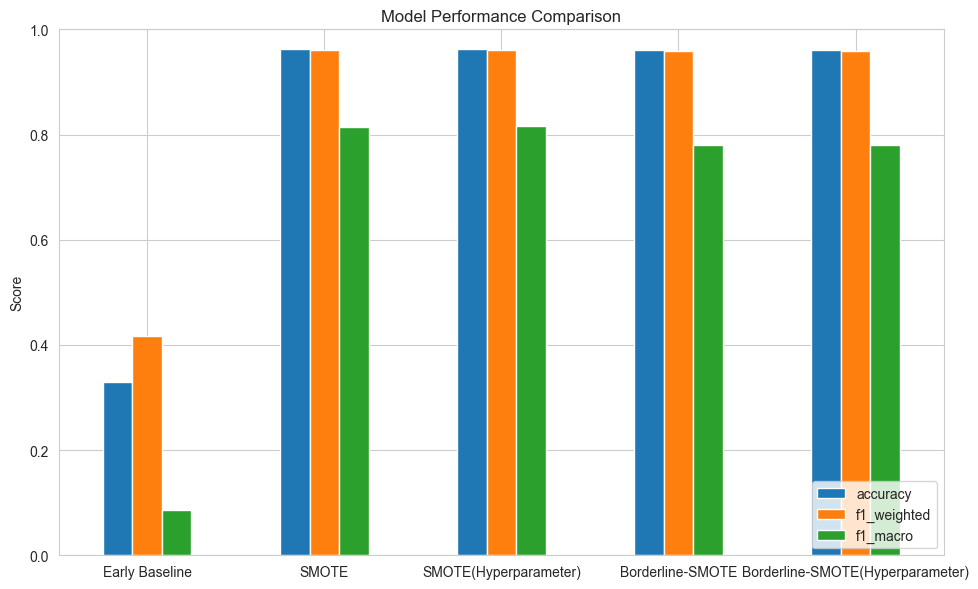

In [25]:
results_df.plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

## Automatically select best model

In [26]:
best_model_name = results_df["f1_macro"].idxmax()
print("Best Model:", best_model_name)

Best Model: SMOTE(Hyperparameter)


## Select + save final model

In [27]:
model_map = {
    "Early Baseline": "rf_early_baseline_model.pkl",
    "SMOTE": "rf_smote_model.pkl",
    "SMOTE(Hyperparameter)": "rf_smote_tuned_model.pkl",
    "Borderline-SMOTE": "rf_borderline_smote_model.pkl",
    "Borderline-SMOTE(Hyperparameter)": "rf_borderline_smote_tuned_model.pkl"
}

best_model = joblib.load(model_map[best_model_name])
joblib.dump(best_model, "final_nids_model.pkl")

['final_nids_model.pkl']

## Add Confusion Matrix

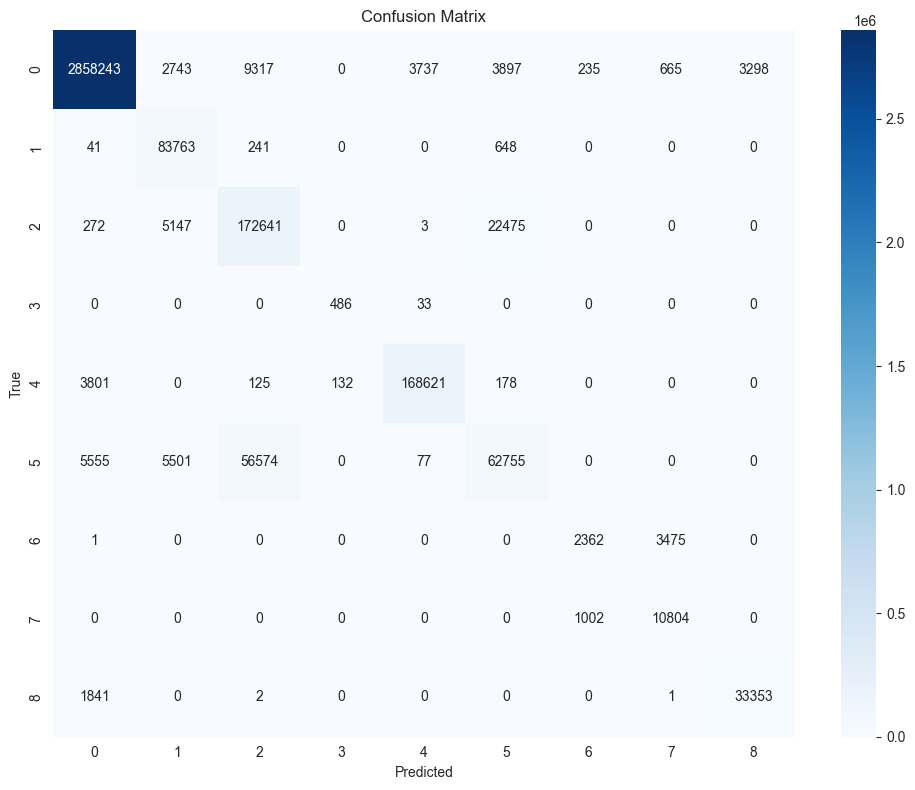

In [28]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

## Test real predictions

In [29]:
best_model = joblib.load("final_nids_model.pkl")
le = joblib.load("label_encoder.pkl")

sample = X_test.iloc[[0]] 

pred = best_model.predict(sample)[0]
true = y_test.iloc[0]

print("True label (encoded):", true)
print("Predicted label (encoded):", pred)

print("True label (text):", le.inverse_transform([true])[0])
print("Predicted label (text):", le.inverse_transform([pred])[0])

True label (encoded): 0
Predicted label (encoded): 0
True label (text): Benign
Predicted label (text): Benign


## Save ALL final artifacts

In [30]:
# Save final artifacts
joblib.dump(best_model, "final_nids_model.pkl")
joblib.dump(le, "label_encoder.pkl")
joblib.dump(selected_features, "features.pkl")

print("Final model + encoder + features saved")

# Cleanup
del best_model, le, selected_features
gc.collect()
print("Memory cleared")

Final model + encoder + features saved
Memory cleared


In [2]:
import pandas as pd
import numpy as np
import sklearn
import imblearn
import joblib
import matplotlib
import seaborn

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)
print("joblib:", joblib.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", seaborn.__version__)

pandas: 3.0.1
numpy: 2.4.3
scikit-learn: 1.8.0
imbalanced-learn: 0.14.1
joblib: 1.5.3
matplotlib: 3.10.8
seaborn: 0.13.2
